# Eigen Motif Syntax via Saturated Mutagenesis

For each test sequence:
1. Generate all single-base mutations (281 pos x 3 alt = 843 mutants)
2. Run forward passes through K562, HepG2, WTC11 fine-tuned models
3. Build mutation-effect matrix E of shape (281, 3) — per-position sensitivity per cell type
4. Eigendecompose to find positional modes that co-vary (shared) or diverge (cell-specific) across cell types
5. Visualize eigenvectors as position tracks + low-dim scatter of positions in PC space

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import sys
import json
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
from sklearn.decomposition import PCA

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, REPO_ROOT)

from alphagenome_pytorch import AlphaGenome
from alphagenome_pytorch.extensions.finetuning.transfer import remove_all_heads
from alphagenome_pytorch.extensions.finetuning.utils import sequence_to_onehot

print(f'torch {torch.__version__}, CUDA: {torch.cuda.is_available()}')

torch 2.10.0+cu128, CUDA: True


In [4]:
ENCODER_DIM = 1536
ENCODER_RESOLUTION_BP = 128


class MPRAHead(nn.Module):
    def __init__(self, n_positions, nl_size=1024, dropout=0.0,
                 activation='relu', pooling_type='flatten', center_bp=256):
        super().__init__()
        self.pooling_type = pooling_type
        self.center_bp = center_bp
        self.n_positions = n_positions
        self._center_window_positions = max(1, center_bp // ENCODER_RESOLUTION_BP)

        hidden_sizes = [nl_size] if isinstance(nl_size, int) else list(nl_size)
        self.norm = nn.LayerNorm(ENCODER_DIM)
        in_dim = n_positions * ENCODER_DIM if pooling_type == 'flatten' else ENCODER_DIM

        layers = []
        for hs in hidden_sizes:
            layers.append(nn.Linear(in_dim, hs))
            in_dim = hs
        self.hidden_layers = nn.ModuleList(layers)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.output = nn.Linear(in_dim, 1)

        if activation == 'gelu':
            self.act = nn.GELU()
        else:
            self.act = nn.ReLU()

    def forward(self, encoder_output):
        x = self.norm(encoder_output)
        if self.pooling_type == 'flatten':
            x = x.flatten(1)
        for layer in self.hidden_layers:
            x = self.act(self.dropout(layer(x)))
        return self.output(x).squeeze(-1)


class AlphaGenomeMPRA(nn.Module):
    def __init__(self, encoder, head):
        super().__init__()
        self.encoder = encoder
        self.head = head

    def forward(self, x):
        # x: (B, 4, L) channels-first
        x = x.transpose(1, 2)  # -> (B, L, 4)
        org_idx = torch.zeros(x.shape[0], dtype=torch.long, device=x.device)
        enc_out = self.encoder(
            x, org_idx, encoder_only=True
        )['encoder_output'].transpose(1, 2)
        return self.head(enc_out)  # (B,)


print('Classes defined.')

Classes defined.


## 1. Model configs & test sequences

In [5]:
WEIGHTS_PATH = os.path.join(REPO_ROOT, 'weights', 'model_fold_0.safetensors')
RESULTS_DIR = os.path.join(REPO_ROOT, 'training', 'results')
DATA_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/test_run_lenti_data'

# Best model per cell type (highest Pearson r)
CELL_TYPE_MODELS = {
    'K562':  'K562_twostep_v4_do075',
    'HepG2': 'HepG2_twostep_v5_do075',
    'WTC11': 'WTC11_twostep_v6_do075',
}

PROMOTER_SEQ = 'TCCATTATATACCCTCTAGTGTCGGTTCACGCAATG'  # 36 bp
RAND_BARCODE = 'AGAGACTGAGGCCAC'                       # 15 bp

import pandas as pd
df = pd.read_csv(os.path.join(DATA_DIR, 'HepG2.tsv'), sep='\t')
df = df[df['rev'] == 0]
test_df = df[df['fold'] == 10].reset_index(drop=True)

N_SEQS = 2
top_df = test_df.nlargest(N_SEQS, 'mean_value').reset_index(drop=True)

X_list = []
seqs_str = []
for _, row in top_df.iterrows():
    construct = row['seq'] + PROMOTER_SEQ + RAND_BARCODE
    seqs_str.append(construct)
    ohe = sequence_to_onehot(construct).astype(np.float32)  # (281, 4)
    X_list.append(torch.from_numpy(ohe).T)  # (4, 281)

X = torch.stack(X_list)
print(f'{N_SEQS} sequences, shape: {X.shape}')
print(f'Expression values: {top_df["mean_value"].tolist()}')

2 sequences, shape: torch.Size([2, 4, 281])
Expression values: [4.41, 4.086]


## 2. Saturated mutagenesis library

In [6]:
BASES = 'ACGT'


def generate_all_single_mutants(onehot):
    """Generate all single-base substitutions.
    
    Args:
        onehot: (4, L) tensor
    Returns:
        mutants: (N_mut, 4, L) tensor
        info: list of (position, ref_base, alt_base)
    """
    L = onehot.shape[1]
    mutants = []
    info = []
    for p in range(L):
        ref_idx = onehot[:, p].argmax().item()
        for alt_idx in range(4):
            if alt_idx == ref_idx:
                continue
            mut = onehot.clone()
            mut[:, p] = 0
            mut[alt_idx, p] = 1
            mutants.append(mut)
            info.append((p, BASES[ref_idx], BASES[alt_idx]))
    return torch.stack(mutants), info


# Generate for each sequence
mutant_libs = []
mutant_infos = []
for si in range(N_SEQS):
    muts, info = generate_all_single_mutants(X[si])
    mutant_libs.append(muts)
    mutant_infos.append(info)
    print(f'Seq {si}: {len(muts)} mutants')

Seq 0: 843 mutants
Seq 1: 843 mutants


## 3. Run ISM forward passes

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def run_ism(model, wt_onehot, mutant_onehots, device, batch_size=64):
    """Run ISM. Returns array of prediction deltas (N_mut,)."""
    model.eval()
    with torch.no_grad():
        wt_pred = model(wt_onehot.unsqueeze(0).to(device)).cpu().item()
        deltas = []
        for i in range(0, len(mutant_onehots), batch_size):
            batch = mutant_onehots[i:i+batch_size].to(device)
            preds = model(batch).cpu().numpy()
            deltas.append(preds - wt_pred)
    return np.concatenate(deltas)


# Run each cell-type model on all sequences
# Store: ism_deltas[seq_idx][cell_type] = (843,) array
ism_deltas = [{} for _ in range(N_SEQS)]
wt_preds = [{} for _ in range(N_SEQS)]

for ct, model_name in CELL_TYPE_MODELS.items():
    print(f'\n=== Loading {ct} ({model_name}) ===')
    ckpt_path = os.path.join(RESULTS_DIR, model_name, 'checkpoints', 'best_stage2.pt')
    
    enc = AlphaGenome.from_pretrained(WEIGHTS_PATH, device='cpu')
    remove_all_heads(enc)
    hd = MPRAHead(n_positions=3, nl_size=1024, dropout=0.0,
                  activation='relu', pooling_type='flatten', center_bp=256)
    
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    
    wm = AlphaGenomeMPRA(enc, hd).to(device).eval()
    
    for si in range(N_SEQS):
        with torch.no_grad():
            wt_p = wm(X[si:si+1].to(device)).cpu().item()
        wt_preds[si][ct] = wt_p
        deltas = run_ism(wm, X[si], mutant_libs[si], device, batch_size=64)
        ism_deltas[si][ct] = deltas
        print(f'  Seq {si}: WT pred={wt_p:.4f}, max|delta|={np.abs(deltas).max():.4f}')
    
    del wm, enc, hd, ckpt
    torch.cuda.empty_cache()

print('\nISM complete.')


=== Loading K562 (K562_twostep_v4_do075) ===
  Seq 0: WT pred=-0.3311, max|delta|=0.3980
  Seq 1: WT pred=-0.0481, max|delta|=0.2928

=== Loading HepG2 (HepG2_twostep_v5_do075) ===
  Seq 0: WT pred=3.6263, max|delta|=1.8497
  Seq 1: WT pred=0.8317, max|delta|=1.0056

=== Loading WTC11 (WTC11_twostep_v6_do075) ===
  Seq 0: WT pred=-0.7373, max|delta|=0.6984
  Seq 1: WT pred=-0.7881, max|delta|=0.6762

ISM complete.


## 4. Build position-level effect matrix & eigendecompose

For each position, take the **max-abs mutation effect** (keeping the sign of the
most impactful substitution) per cell type. This gives `E` of shape `(281, 3)`.

With 3 cell types, the covariance matrix `E.T @ E` is `(3, 3)` and its eigenvectors
live in cell-type space. The position covariance `E @ E.T` is `(281, 281)` with
rank 3 — yielding exactly 3 positional modes.

In [8]:
cell_types = list(CELL_TYPE_MODELS.keys())  # ['K562', 'HepG2', 'WTC11']
L = X.shape[2]  # 281


def build_effect_matrix(deltas_dict, mut_info, n_positions, cell_types):
    """Build (n_positions, n_cell_types) matrix.
    
    Per position: pick the mutation with largest absolute effect
    (averaged across cell types), keep its signed effect per cell type.
    """
    n_ct = len(cell_types)
    # Reshape deltas to (n_positions, 3_alts, n_cell_types)
    D = np.zeros((n_positions, 3, n_ct))
    for ci, ct in enumerate(cell_types):
        D[:, :, ci] = deltas_dict[ct].reshape(n_positions, 3)
    
    # For each position, pick the alt allele with max mean |effect| across cell types
    mean_abs = np.abs(D).mean(axis=2)  # (281, 3)
    best_alt = mean_abs.argmax(axis=1)  # (281,)
    
    E = np.zeros((n_positions, n_ct))
    for p in range(n_positions):
        E[p, :] = D[p, best_alt[p], :]
    
    return E


# Build E for each sequence
E_all = []
for si in range(N_SEQS):
    E = build_effect_matrix(ism_deltas[si], mutant_infos[si], L, cell_types)
    E_all.append(E)
    print(f'Seq {si}: E shape {E.shape}, range [{E.min():.4f}, {E.max():.4f}]')

Seq 0: E shape (281, 3), range [-1.8497, 0.6984]
Seq 1: E shape (281, 3), range [-0.9020, 1.0056]


In [9]:
# Eigendecompose for each sequence
for si in range(N_SEQS):
    E = E_all[si]
    
    # Center
    E_centered = E - E.mean(axis=0)
    
    # PCA in cell-type space: what linear combinations of cell types explain position variance?
    pca = PCA(n_components=3)
    scores = pca.fit_transform(E_centered)  # (281, 3) — position coordinates in PC space
    
    print(f'\n=== Seq {si} ===')
    print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
    print(f'Eigenvalues: {pca.explained_variance_}')
    print(f'\nPC loadings (rows=PCs, cols={cell_types}):')
    for pc_i in range(3):
        loadings = pca.components_[pc_i]
        desc = ', '.join(f'{ct}: {w:+.3f}' for ct, w in zip(cell_types, loadings))
        print(f'  PC{pc_i+1} ({pca.explained_variance_ratio_[pc_i]*100:.1f}%): [{desc}]')


=== Seq 0 ===
Explained variance ratio: [0.8529547  0.11678381 0.03026149]
Eigenvalues: [0.09054804 0.01239755 0.0032125 ]

PC loadings (rows=PCs, cols=['K562', 'HepG2', 'WTC11']):
  PC1 (85.3%): [K562: -0.001, HepG2: +0.979, WTC11: +0.204]
  PC2 (11.7%): [K562: +0.569, HepG2: -0.168, WTC11: +0.805]
  PC3 (3.0%): [K562: +0.822, HepG2: +0.117, WTC11: -0.557]

=== Seq 1 ===
Explained variance ratio: [0.88946447 0.09675283 0.01378269]
Eigenvalues: [0.09016371 0.00980769 0.00139713]

PC loadings (rows=PCs, cols=['K562', 'HepG2', 'WTC11']):
  PC1 (88.9%): [K562: +0.160, HepG2: +0.924, WTC11: +0.348]
  PC2 (9.7%): [K562: +0.062, HepG2: -0.362, WTC11: +0.930]
  PC3 (1.4%): [K562: +0.985, HepG2: -0.127, WTC11: -0.115]


## 5. Eigenvector position tracks

Each PC's scores along the 281 positions show **which positions load on that mode**.
Tall bars = positions whose mutation effects align with that PC direction.

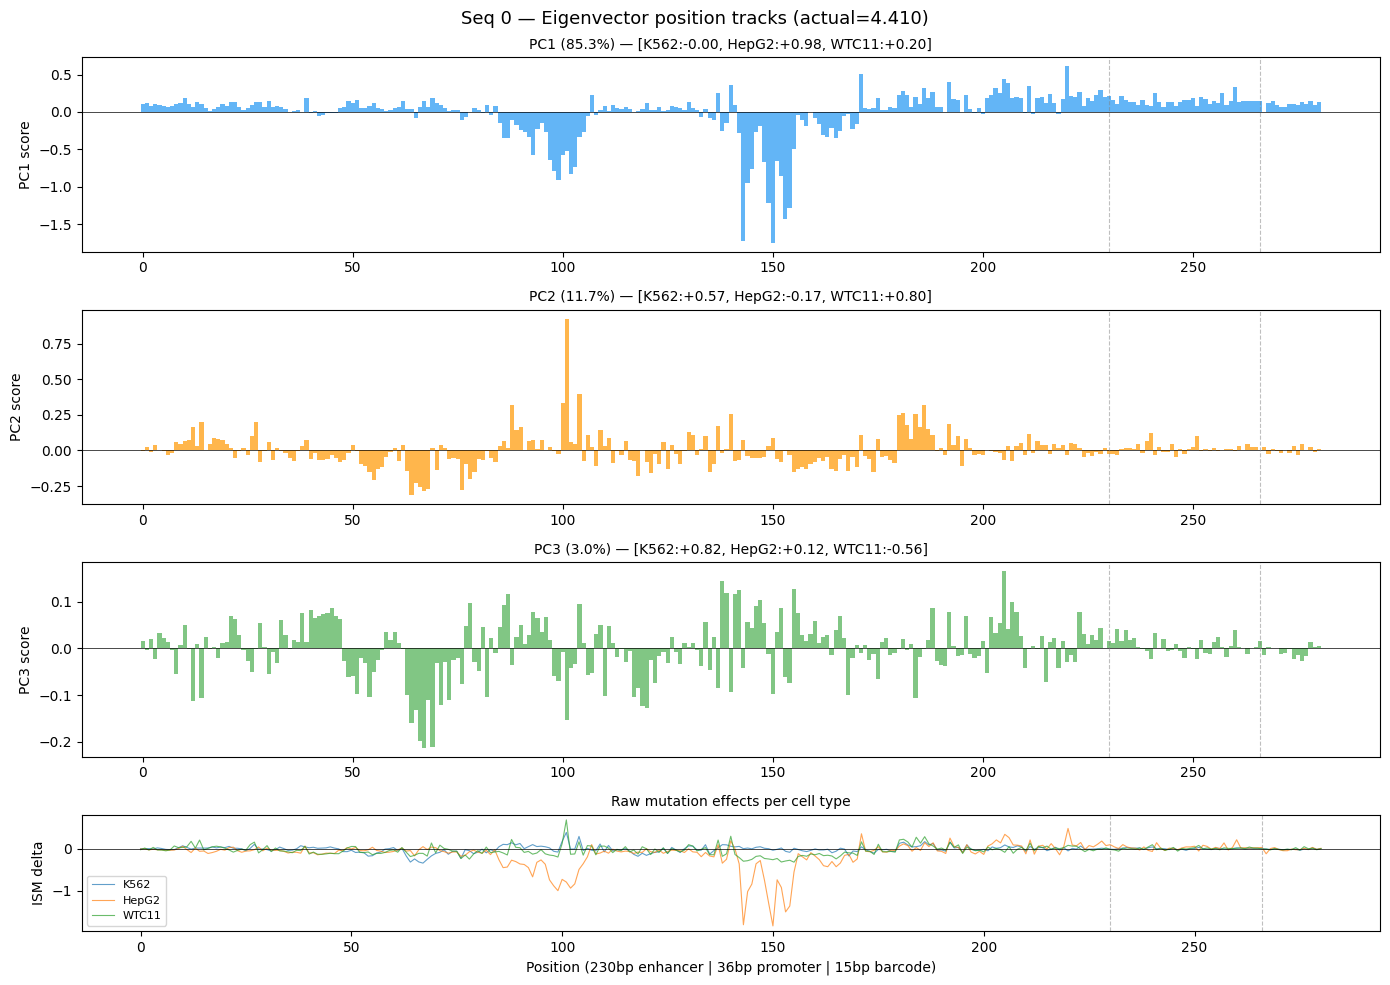

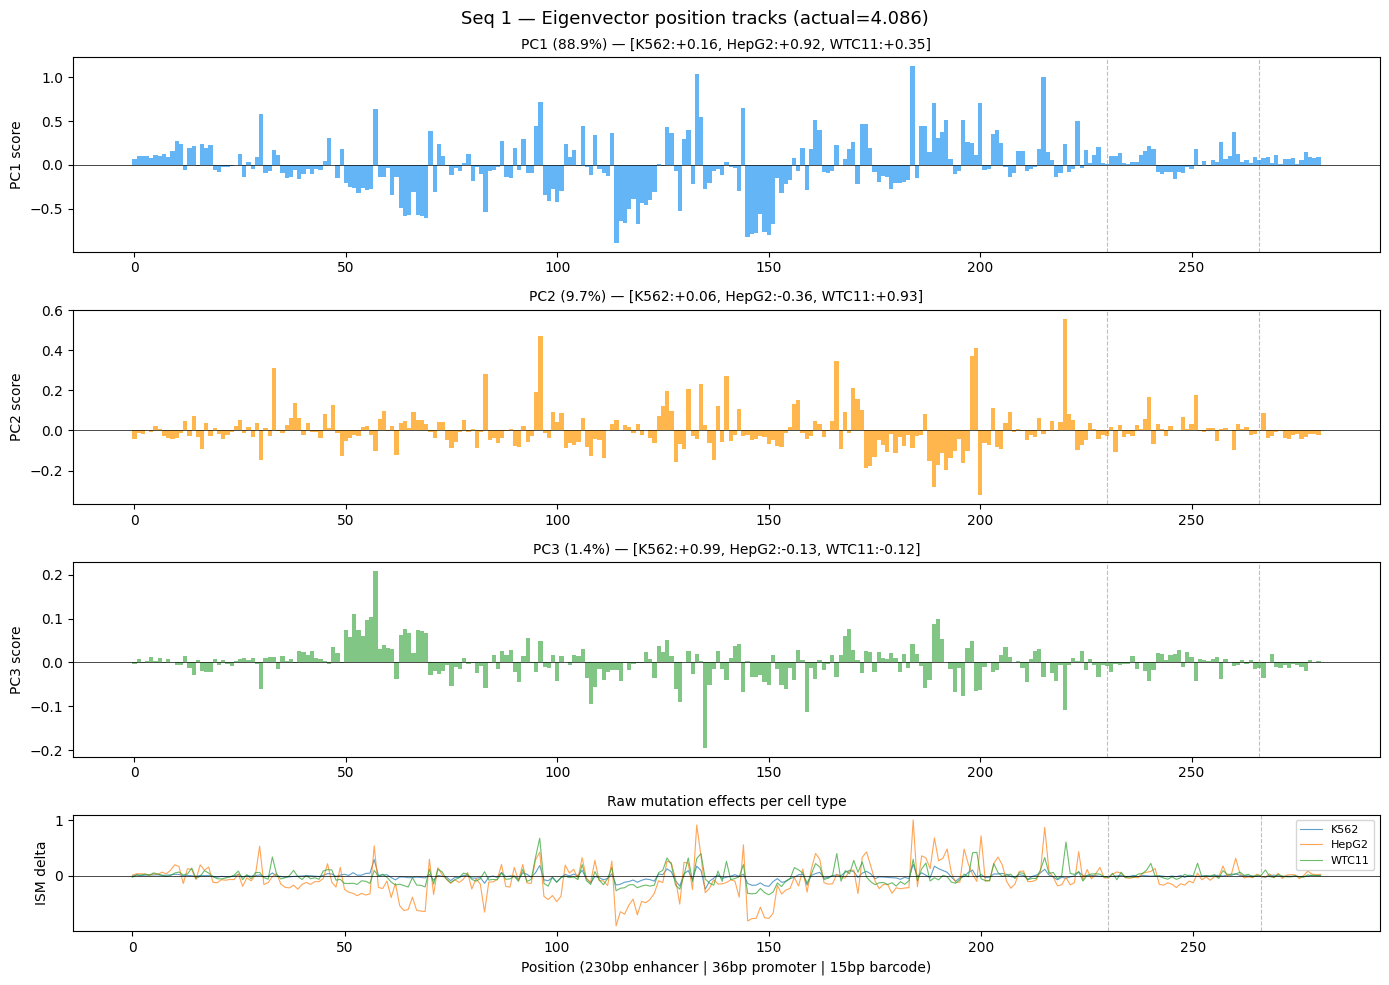

In [10]:
for si in range(N_SEQS):
    E = E_all[si]
    E_centered = E - E.mean(axis=0)
    pca = PCA(n_components=3)
    scores = pca.fit_transform(E_centered)  # (281, 3)
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1, 1, 0.6]})
    fig.suptitle(f'Seq {si} — Eigenvector position tracks (actual={top_df.iloc[si]["mean_value"]:.3f})',
                 fontsize=13)
    
    positions = np.arange(L)
    colors = ['#2196F3', '#FF9800', '#4CAF50']
    
    for pc_i in range(3):
        ax = axes[pc_i]
        ax.bar(positions, scores[:, pc_i], width=1.0, color=colors[pc_i], alpha=0.7)
        ax.axhline(0, color='k', linewidth=0.5)
        
        # Mark enhancer / promoter / barcode regions
        ax.axvline(230, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.axvline(266, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        
        loadings = pca.components_[pc_i]
        loading_str = ', '.join(f'{ct}:{w:+.2f}' for ct, w in zip(cell_types, loadings))
        var_pct = pca.explained_variance_ratio_[pc_i] * 100
        ax.set_ylabel(f'PC{pc_i+1} score')
        ax.set_title(f'PC{pc_i+1} ({var_pct:.1f}%) — [{loading_str}]', fontsize=10)
    
    # Bottom panel: raw mutation effects per cell type
    ax = axes[3]
    for ci, ct in enumerate(cell_types):
        ax.plot(positions, E[:, ci], label=ct, alpha=0.7, linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(230, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(266, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Position (230bp enhancer | 36bp promoter | 15bp barcode)')
    ax.set_ylabel('ISM delta')
    ax.legend(fontsize=8)
    ax.set_title('Raw mutation effects per cell type', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## 6. Low-dimensional PC scatter

Each point = one position. Coordinates = PC scores.  
Colored by position along the sequence to reveal spatial structure.  
Positions that cluster together are **co-regulated** — mutating them has correlated effects across cell types.

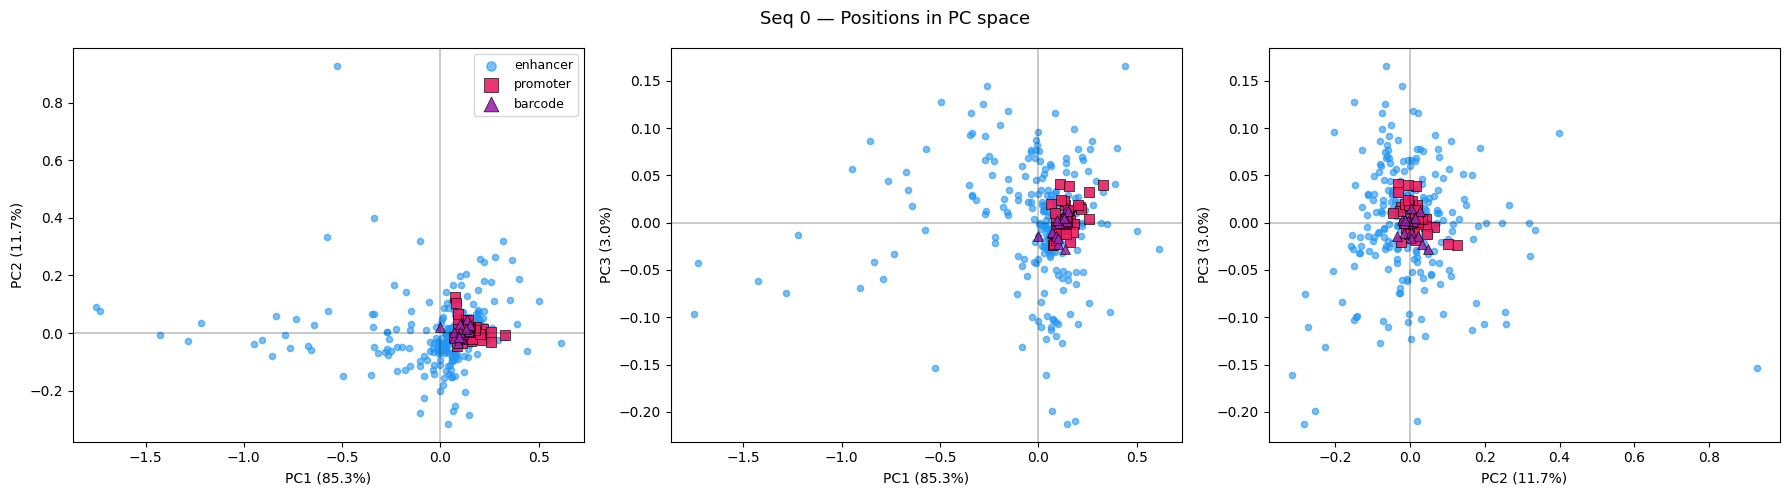

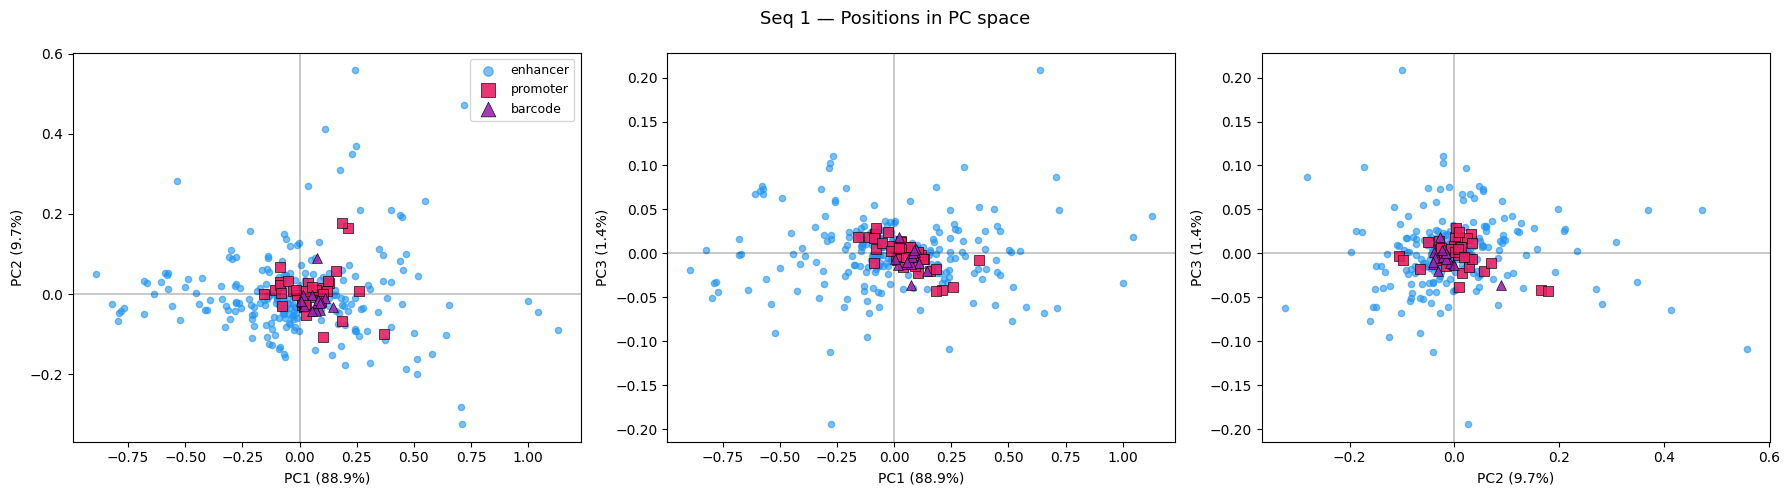

In [14]:
# Region colors used throughout
REGION_COLORS = {'enhancer': '#2196F3', 'promoter': '#E91E63', 'barcode': '#9C27B0'}
enhancer_mask = np.arange(L) < 230
promoter_mask = (np.arange(L) >= 230) & (np.arange(L) < 266)
barcode_mask = np.arange(L) >= 266

for si in range(N_SEQS):
    E = E_all[si]
    E_centered = E - E.mean(axis=0)
    pca = PCA(n_components=3)
    scores = pca.fit_transform(E_centered)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Seq {si} — Positions in PC space', fontsize=13)
    
    pc_pairs = [(0, 1), (0, 2), (1, 2)]
    for ax_i, (pc_a, pc_b) in enumerate(pc_pairs):
        ax = axes[ax_i]
        
        ax.scatter(scores[enhancer_mask, pc_a], scores[enhancer_mask, pc_b],
                   c=REGION_COLORS['enhancer'], s=20, marker='o', alpha=0.6, label='enhancer')
        ax.scatter(scores[promoter_mask, pc_a], scores[promoter_mask, pc_b],
                   c=REGION_COLORS['promoter'], s=50, marker='s', alpha=0.9, label='promoter',
                   edgecolors='k', linewidths=0.5)
        ax.scatter(scores[barcode_mask, pc_a], scores[barcode_mask, pc_b],
                   c=REGION_COLORS['barcode'], s=50, marker='^', alpha=0.9, label='barcode',
                   edgecolors='k', linewidths=0.5)
        
        var_a = pca.explained_variance_ratio_[pc_a] * 100
        var_b = pca.explained_variance_ratio_[pc_b] * 100
        ax.set_xlabel(f'PC{pc_a+1} ({var_a:.1f}%)')
        ax.set_ylabel(f'PC{pc_b+1} ({var_b:.1f}%)')
        ax.axhline(0, color='k', linewidth=0.3)
        ax.axvline(0, color='k', linewidth=0.3)
        if ax_i == 0:
            ax.legend(fontsize=9, markerscale=1.5)
    
    plt.tight_layout()
    plt.show()

## 7. Pairwise cell-type effect scatter

Raw ISM effects plotted cell-type vs cell-type.  
- **Diagonal**: shared regulation (mutation affects both equally)  
- **Off-diagonal**: cell-type-specific positions

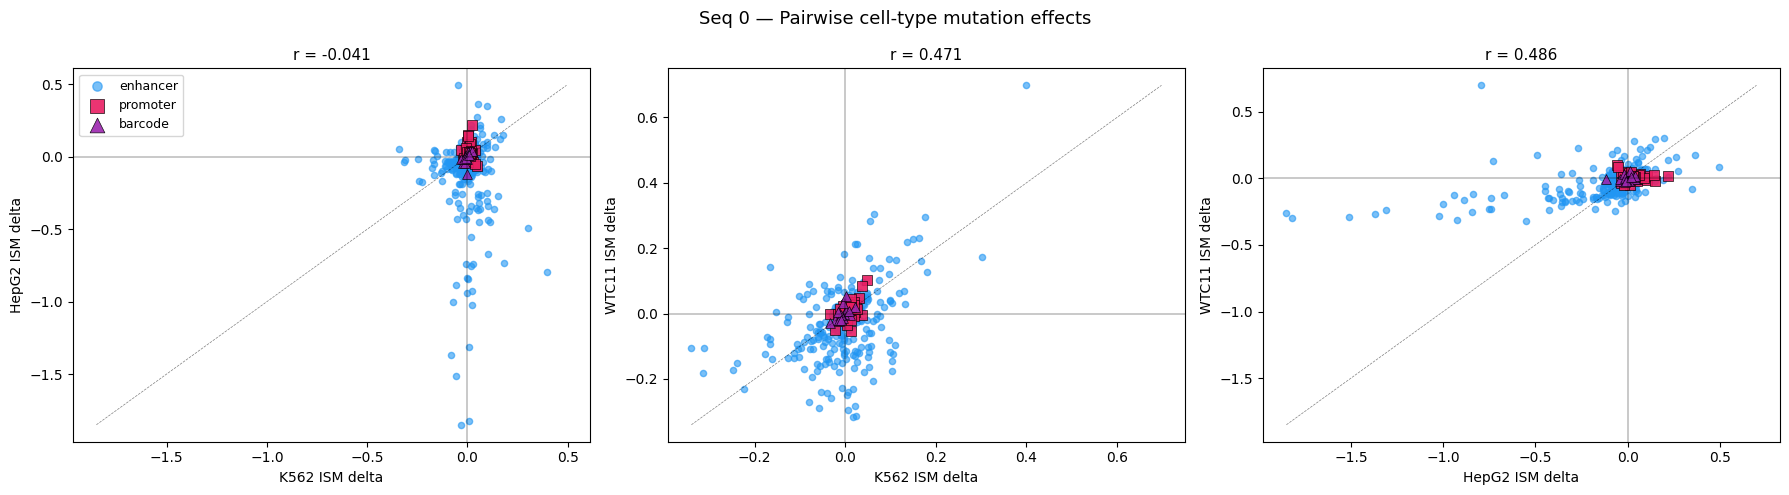

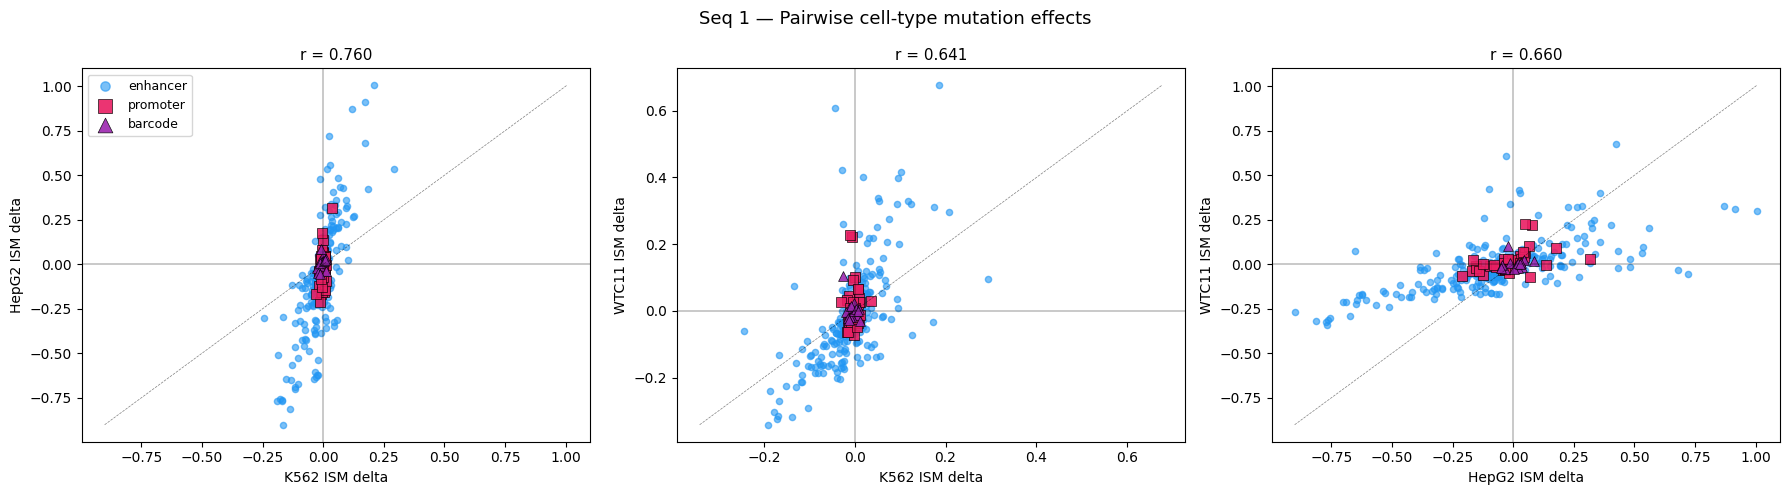

In [15]:
for si in range(N_SEQS):
    E = E_all[si]
    
    ct_pairs = [(0, 1), (0, 2), (1, 2)]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Seq {si} — Pairwise cell-type mutation effects', fontsize=13)
    
    for ax_i, (ci_a, ci_b) in enumerate(ct_pairs):
        ax = axes[ax_i]
        
        ax.scatter(E[enhancer_mask, ci_a], E[enhancer_mask, ci_b],
                   c=REGION_COLORS['enhancer'], s=20, marker='o', alpha=0.6, label='enhancer')
        ax.scatter(E[promoter_mask, ci_a], E[promoter_mask, ci_b],
                   c=REGION_COLORS['promoter'], s=50, marker='s', alpha=0.9, label='promoter',
                   edgecolors='k', linewidths=0.5)
        ax.scatter(E[barcode_mask, ci_a], E[barcode_mask, ci_b],
                   c=REGION_COLORS['barcode'], s=50, marker='^', alpha=0.9, label='barcode',
                   edgecolors='k', linewidths=0.5)
        
        # Diagonal line
        lims = [min(E[:, ci_a].min(), E[:, ci_b].min()),
                max(E[:, ci_a].max(), E[:, ci_b].max())]
        ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5)
        ax.axhline(0, color='k', linewidth=0.3)
        ax.axvline(0, color='k', linewidth=0.3)
        
        r = np.corrcoef(E[:, ci_a], E[:, ci_b])[0, 1]
        ax.set_xlabel(f'{cell_types[ci_a]} ISM delta')
        ax.set_ylabel(f'{cell_types[ci_b]} ISM delta')
        ax.set_title(f'r = {r:.3f}', fontsize=11)
        if ax_i == 0:
            ax.legend(fontsize=9, markerscale=1.5)
    
    plt.tight_layout()
    plt.show()

## 8. Annotate outlier positions

Flag positions with high cell-type-specific effects (far from diagonal in pairwise plots).
Print the local sequence context around these positions for motif identification.

In [16]:
for si in range(N_SEQS):
    E = E_all[si]
    seq = seqs_str[si]
    
    print(f'\n{"="*60}')
    print(f'Seq {si} (actual={top_df.iloc[si]["mean_value"]:.3f})')
    print(f'{"="*60}')
    
    # PCA
    E_centered = E - E.mean(axis=0)
    pca = PCA(n_components=3)
    scores = pca.fit_transform(E_centered)
    
    for pc_i in range(3):
        loadings = pca.components_[pc_i]
        loading_str = ', '.join(f'{ct}:{w:+.3f}' for ct, w in zip(cell_types, loadings))
        var_pct = pca.explained_variance_ratio_[pc_i] * 100
        
        print(f'\nPC{pc_i+1} ({var_pct:.1f}%) [{loading_str}]')
        
        # Top positions by |score| on this PC
        top_pos = np.argsort(np.abs(scores[:, pc_i]))[::-1][:10]
        
        for rank, p in enumerate(top_pos):
            # Extract 11bp context centered on position
            start = max(0, p - 5)
            end = min(len(seq), p + 6)
            context = seq[start:end]
            # Mark the central base
            rel_p = p - start
            context_marked = context[:rel_p] + f'[{context[rel_p]}]' + context[rel_p+1:]
            
            region = 'enh' if p < 230 else ('prom' if p < 266 else 'bc')
            effects = ', '.join(f'{ct}:{E[p, ci]:+.4f}' for ci, ct in enumerate(cell_types))
            print(f'  {rank+1:2d}. pos={p:3d} ({region:4s}) score={scores[p, pc_i]:+.4f}'
                  f'  ...{context_marked}...  [{effects}]')


Seq 0 (actual=4.410)

PC1 (85.3%) [K562:-0.001, HepG2:+0.979, WTC11:+0.204]
   1. pos=150 (enh ) score=-1.7519  ...CTAGA[C]ATGCC...  [K562:-0.0308, HepG2:-1.8497, WTC11:-0.2584]
   2. pos=143 (enh ) score=-1.7315  ...GATTT[G]TCTAG...  [K562:+0.0065, HepG2:-1.8213, WTC11:-0.2948]
   3. pos=153 (enh ) score=-1.4283  ...GACAT[G]CCTGC...  [K562:-0.0571, HepG2:-1.5128, WTC11:-0.2891]
   4. pos=154 (enh ) score=-1.2858  ...ACATG[C]CTGCA...  [K562:-0.0801, HepG2:-1.3710, WTC11:-0.2711]
   5. pos=149 (enh ) score=-1.2203  ...TCTAG[A]CATGC...  [K562:+0.0059, HepG2:-1.3102, WTC11:-0.2413]
   6. pos=144 (enh ) score=-0.9486  ...ATTTG[T]CTAGA...  [K562:+0.0221, HepG2:-1.0242, WTC11:-0.2822]
   7. pos= 99 (enh ) score=-0.9092  ...TGAGA[C]ATGCC...  [K562:-0.0742, HepG2:-1.0024, WTC11:-0.1939]
   8. pos=152 (enh ) score=-0.8583  ...AGACA[T]GCCTG...  [K562:+0.0233, HepG2:-0.9253, WTC11:-0.3136]
   9. pos=102 (enh ) score=-0.8358  ...GACAT[G]CCCAC...  [K562:-0.0039, HepG2:-0.9413, WTC11:-0.1272]
  10.

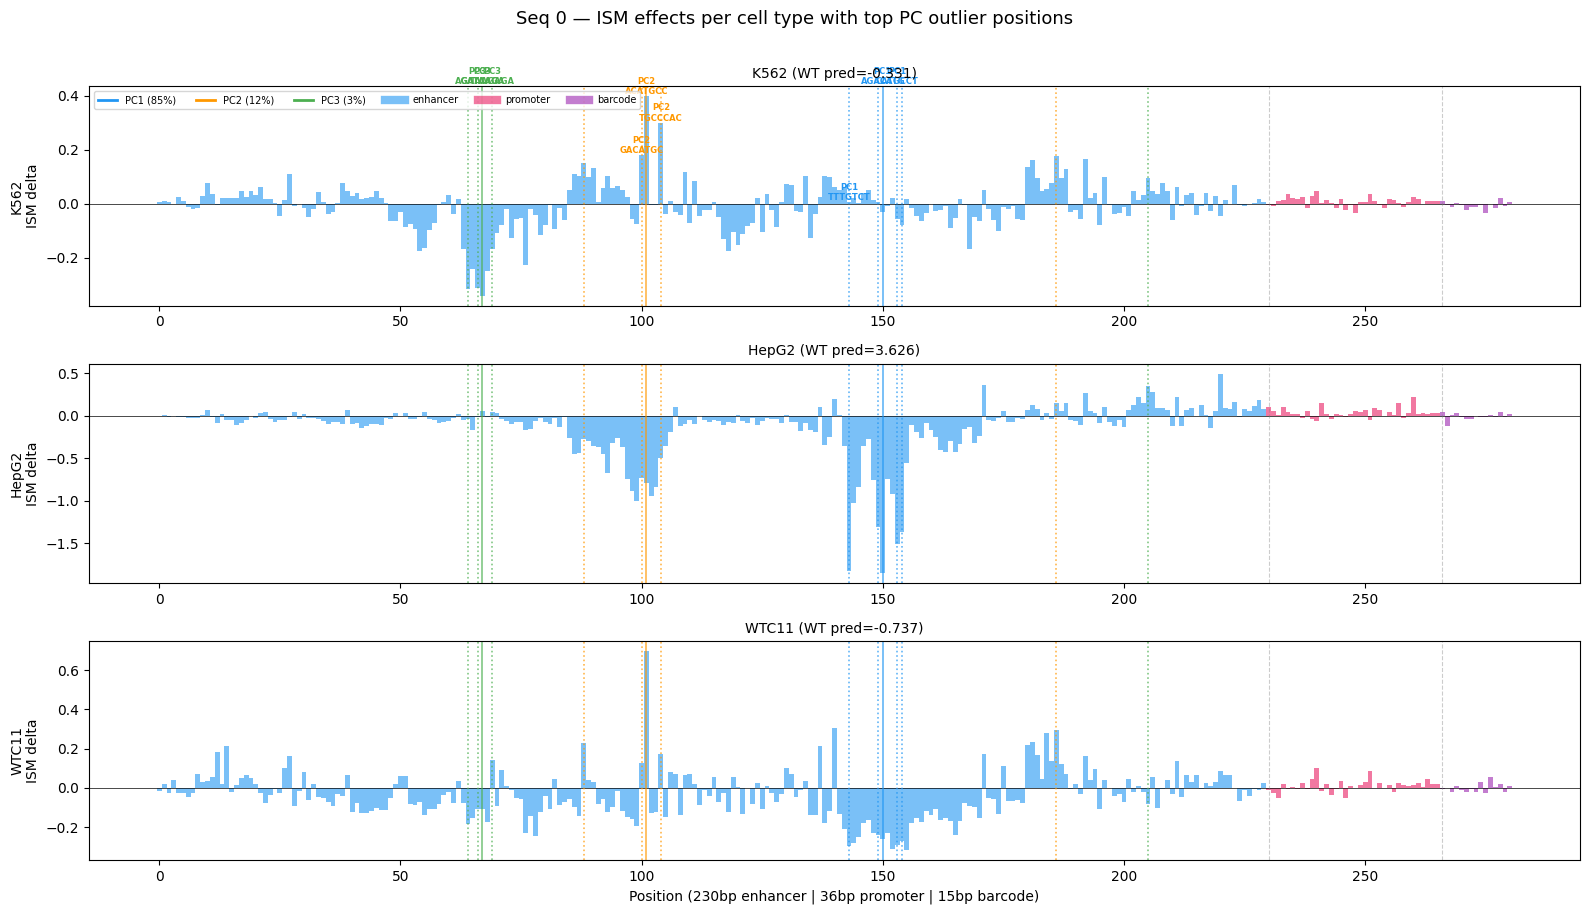

In [17]:
# Seq 0: ISM tracks per cell type with top PC positions annotated
si = 0
E = E_all[si]
seq = seqs_str[si]

E_centered = E - E.mean(axis=0)
pca = PCA(n_components=3)
scores = pca.fit_transform(E_centered)

# Collect top 5 positions per PC
N_TOP = 5
pc_colors = ['#2196F3', '#FF9800', '#4CAF50']
pc_top_positions = {}
for pc_i in range(3):
    top_pos = np.argsort(np.abs(scores[:, pc_i]))[::-1][:N_TOP]
    pc_top_positions[pc_i] = top_pos

# --- Plot: 3 rows (one per cell type), ISM bar tracks with annotated outliers ---
fig, axes = plt.subplots(3, 1, figsize=(16, 9))
fig.suptitle(f'Seq {si} — ISM effects per cell type with top PC outlier positions',
             fontsize=13, y=1.01)

positions = np.arange(L)

# Build per-position region colors for bars
bar_colors = np.array([REGION_COLORS['enhancer']] * L)
bar_colors[promoter_mask] = REGION_COLORS['promoter']
bar_colors[barcode_mask] = REGION_COLORS['barcode']

for ci, ct in enumerate(cell_types):
    ax = axes[ci]
    
    # ISM bars colored by region
    ax.bar(positions, E[:, ci], width=1.0, color=bar_colors, alpha=0.6)
    ax.axhline(0, color='k', linewidth=0.5)
    
    # Region boundaries
    ax.axvline(230, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axvline(266, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
    
    # Overlay top PC positions as vertical lines + text labels
    for pc_i in range(3):
        loadings = pca.components_[pc_i]
        var_pct = pca.explained_variance_ratio_[pc_i] * 100
        for rank, p in enumerate(pc_top_positions[pc_i]):
            ax.axvline(p, color=pc_colors[pc_i], linewidth=1.2, alpha=0.7,
                       linestyle='-' if rank == 0 else ':')
            # Label only on the top row to avoid clutter
            if ci == 0 and rank < 3:
                region = 'enh' if p < 230 else ('prom' if p < 266 else 'bc')
                start = max(0, p - 3)
                end = min(len(seq), p + 4)
                context = seq[start:end]
                ax.text(p, ax.get_ylim()[1] if E[p, ci] < 0 else E[p, ci],
                        f'PC{pc_i+1}\n{context}', fontsize=6, ha='center', va='bottom',
                        color=pc_colors[pc_i], fontweight='bold')
    
    wt_pred = wt_preds[si][ct]
    ax.set_ylabel(f'{ct}\nISM delta')
    ax.set_title(f'{ct} (WT pred={wt_pred:.3f})', fontsize=10)
    if ci == 2:
        ax.set_xlabel('Position (230bp enhancer | 36bp promoter | 15bp barcode)')

# Legend for PCs
from matplotlib.lines import Line2D
pc_legend = [Line2D([0], [0], color=pc_colors[i], linewidth=2,
             label=f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.0f}%)')
             for i in range(3)]
region_legend = [Line2D([0], [0], color=REGION_COLORS[r], linewidth=6, alpha=0.6,
                 label=r) for r in ['enhancer', 'promoter', 'barcode']]
axes[0].legend(handles=pc_legend + region_legend, fontsize=7, ncol=6,
               loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

## 9. Seq 0 — ISM tracks with top PC outlier positions annotated

Three rows = K562, HepG2, WTC11 ISM effect tracks (same data, different cell-type models).
Vertical lines mark the top 5 positions from each PC, colored by PC.